# 1. ETL
### 1.1 Initial Data Profiling
Load all 5 datasets and use the `head()` function alongside `display()` to visually inspect the first few rows. This helps us understand the structure and format of our raw data

In [1]:
import pandas as pd

folder_path = 'data/'
df_catalog = pd.read_csv(f'{folder_path}streaming_catalog.csv')

#load all 5 datasets into a dictionary
datasets = {
    'Streaming Catalog': pd.read_csv(f'{folder_path}streaming_catalog.csv'),
    'Platform Summary': pd.read_csv(f'{folder_path}platform_summary.csv'),
    'Genre Summary': pd.read_csv(f'{folder_path}genre_summary.csv'),
    'Country Summary': pd.read_csv(f'{folder_path}country_summary.csv'),
    'Yearly Release Trends': pd.read_csv(f'{folder_path}yearly_release_trends.csv')
}

#inspect the first 5 rows of each dataset
for table_name, df in datasets.items():
    print(f'\n--- {table_name} (Rows: {df.shape[0]}, Columns: {df.shape[1]}) ---')
    display(df.head())


--- Streaming Catalog (Rows: 15000, Columns: 25) ---


,show_id,title,type,platform,primary_genre,genres,director,cast,country,language,...,num_seasons,num_episodes,imdb_rating,rotten_tomatoes_score,imdb_votes,budget_million_usd,production_company,awards_won,hours_watched_million,description
0,s1,When the Stars Fall,Movie,Netflix,Drama,"Drama, War, Mystery",David Tarantino,"Brad Pitt, Marion Cotillard",Germany,German,...,NaN,NaN,6.3,56,11754,15.7,Marvel Studios,0,7,"As a deadly accident unfolds, criminal discove..."
1,s2,A Silent Echo,Movie,Amazon Prime Video,Thriller,"Thriller, Adventure",Bong Nolan,"Park Seo-joon, Lupita Nyong'o",France,French,...,NaN,NaN,7.5,80,4602,184.9,Illumination,0,4,A series of strange events leads detective int...
2,s3,Between Lives,Movie,Netflix,Comedy,"Comedy, Mystery",Hirokazu DuVernay,"Masami Nagasawa, Viola Davis, IU, Priyanka Chopra",South Korea,Korean,...,NaN,NaN,8.6,82,19226,17.5,Skydance Media,1,31,"When artist meets a charming stranger, their l..."
3,s4,A Silent Echo,Movie,Disney+,Thriller,Thriller,Akira Zhao,"Meryl Streep, Sakura Ando, Penélope Cruz",India,Hindi,...,NaN,NaN,5.5,73,90507,7.0,Working Title Films,0,51,"When mother witnesses a crime, they become the..."
4,s5,Labyrinth,Movie,Amazon Prime Video,Action,Action,Akira Blanchett,"Amitabh Bachchan, Idris Elba",Mexico,Spanish,...,NaN,NaN,6.1,62,6487,18.0,Apple Studios,0,12,A former spy is pulled back into action when a...



--- Platform Summary (Rows: 10, Columns: 10) ---


,platform,total_titles,movies,tv_shows,avg_imdb,avg_rt,avg_votes,total_hours_watched_million,total_awards,top_genre
0,Amazon Prime Video,3341,1921,1420,6.78,67.33,56798.87,259376,1003,Drama
1,Apple TV+,734,428,306,7.12,70.51,41406.86,36664,270,Drama
2,Crunchyroll,144,77,67,6.76,66.22,57205.21,9831,37,Drama
3,Disney+,1990,1143,847,6.79,67.36,47726.16,134820,584,Drama
4,HBO Max,1228,700,528,7.04,70.11,48625.53,81195,466,Drama



--- Genre Summary (Rows: 21, Columns: 7) ---


,primary_genre,total_titles,avg_imdb,avg_rt,total_hours_watched_million,avg_budget,total_awards
0,Action,1078,6.78,67.18,72029,49.17,321
1,Adventure,332,6.86,67.90,29049,19.63,104
2,Animation,876,6.80,67.75,72738,52.61,267
3,Anime,287,6.84,67.46,28260,NaN,88
4,Comedy,2180,6.86,68.50,152111,20.30,694



--- Country Summary (Rows: 24, Columns: 5) ---


,country,total_titles,avg_imdb,top_platform,top_genre
0,Argentina,149,6.70,Netflix,Drama
1,Australia,294,6.74,Netflix,Drama
2,Brazil,301,6.85,Amazon Prime Video,Drama
3,Canada,440,6.76,Netflix,Drama
4,China,220,6.84,Netflix,Comedy



--- Yearly Release Trends (Rows: 47, Columns: 6) ---


,release_year,total_titles,movies,tv_shows,avg_imdb,avg_budget
0,1980,87,52,35,6.56,29.06
1,1981,81,40,41,6.59,21.25
2,1982,79,51,28,6.75,31.62
3,1983,86,49,37,6.68,20.77
4,1984,91,46,45,6.75,33.23


### 1.2 Data Types Inspection
Before cleaning the data, we must verify that all columns are assigned the correct data types (e.g., ensuring numbers are floats/integers and text is categorized as objects). This prevents errors in mathematical calculations and modeling later on

In [2]:
print("Data Types Inspection across all datasets:\n" + "-"*45)
for dataset_name, df_current in datasets.items():
    print(f"\nDataset: {dataset_name}")
    dtypes_df = pd.DataFrame(df_current.dtypes, columns=['Data Type'])
    display(dtypes_df)

Data Types Inspection across all datasets:
---------------------------------------------

Dataset: Streaming Catalog


,Data Type
show_id,str
title,str
type,str
platform,str
primary_genre,str
genres,str
director,str
cast,str
country,str
language,str



Dataset: Platform Summary


,Data Type
platform,str
total_titles,int64
movies,int64
tv_shows,int64
avg_imdb,float64
avg_rt,float64
avg_votes,float64
total_hours_watched_million,int64
total_awards,int64
top_genre,str



Dataset: Genre Summary


,Data Type
primary_genre,str
total_titles,int64
avg_imdb,float64
avg_rt,float64
total_hours_watched_million,int64
avg_budget,float64
total_awards,int64



Dataset: Country Summary


,Data Type
country,str
total_titles,int64
avg_imdb,float64
top_platform,str
top_genre,str



Dataset: Yearly Release Trends


,Data Type
release_year,int64
total_titles,int64
movies,int64
tv_shows,int64
avg_imdb,float64
avg_budget,float64


### 1.3 Missing Values Analysis - Counts & Proportions
Calculate the total count and proportion of missing values (Nulls) for every single column across all 5 datasets to determine our data cleaning strategy

In [ ]:
import pandas as pd

#calculate missing values, zeros, and proportions for all 5 tables
for table_name, df in datasets.items():
    print(f'--- Data Quality Report: {table_name} ---')
    
    #NaN, None
    missing_counts = df.isnull().sum()
    
    #count mathematical zeros, only applied to numeric columns to avoid errors
    numeric_cols = df.select_dtypes(include=['number']).columns
    zero_counts = pd.Series(0, index=df.columns) # Initialize with 0 for all columns
    zero_counts[numeric_cols] = (df[numeric_cols] == 0).sum()
    
    #calculate total NaN & 0
    total_empty_counts = missing_counts + zero_counts
    total_empty_proportions = (total_empty_counts / len(df) * 100).round(2)
    
    dqa_summary = pd.DataFrame({
        'NaN Count': missing_counts,
        'Zero Count': zero_counts,
        'Total Empty (NaN+0)': total_empty_counts,
        'Proportion Empty (%)': total_empty_proportions
    })
    
    #show only columns that actually have some form of missing/zero data
    display(dqa_summary[dqa_summary['Total Empty (NaN+0)'] > 0])
    print("\n")

--- Data Quality Report: Streaming Catalog ---


,NaN Count,Zero Count,Total Empty (NaN+0),Proportion Empty (%)
director,5076,0,5076,33.84
duration_minutes,6296,0,6296,41.97
num_seasons,8704,0,8704,58.03
num_episodes,8704,0,8704,58.03
budget_million_usd,6296,0,6296,41.97
awards_won,0,12516,12516,83.44
hours_watched_million,0,2032,2032,13.55




--- Data Quality Report: Platform Summary ---


,NaN Count,Zero Count,Total Empty (NaN+0),Proportion Empty (%)




--- Data Quality Report: Genre Summary ---


,NaN Count,Zero Count,Total Empty (NaN+0),Proportion Empty (%)
avg_budget,6,0,6,28.57




--- Data Quality Report: Country Summary ---


,NaN Count,Zero Count,Total Empty (NaN+0),Proportion Empty (%)




--- Data Quality Report: Yearly Release Trends ---


,NaN Count,Zero Count,Total Empty (NaN+0),Proportion Empty (%)


### Missing Values and Zero Value Analysis

A profiling of the missing (NaN) and zero value distributions across the datasets highlights specific areas that require our attention:

* **Genuine Zero Values ('awards_won'):** Winning a cinematic award is a rare and significant achievement. Therefore, the zeros in this column represent a genuine absence of awards rather than missing data. We made a conscious decision to retain these zeros exactly as they are
* **Zero Value Anomalies ('hours_watched_million'):** This column contains literal zeros. In streaming datasets, a literal zero typically indicates unrecorded metrics rather than absolutely zero views. We will fill these performance metrics using the median
* **Structural Missingness ('num_seasons' & 'num_episodes'):** The missing values in these columns are a structural necessity, as these attributes apply exclusively to TV shows
* **Genre Level Budget Gaps ('avg_budget' in Genre Summary):** The summary table contains missing budget values. We will fill these gaps using the median to maintain complete records for genre based financial analysis

**Methodological Imputation Strategy Note:** For highly skewed financial and operational metrics (like watch hours and budgets), median imputation is preferred over mean imputation. The median is a robust central estimator that prevents extreme outliers (e.g., mega blockbusters) from artificially inflating our imputed baseline values

### 1.3.1 Investigating Missing Budget Data 
During our initial data profiling, we observed that the `budget_million_usd` column contains over 40% missing values. Standard practice might dictate dropping this column entirely. However, before doing so, we must investigate if this absence is structural. We will analyze the distribution of missing budgets to see if it correlates with the content type (Movies vs. TV Shows), which could indicate that budget is simply a format specific feature

In [4]:
#instead of blindly dropping missing values, we first investigate if the missing data has a structural reason
budget_breakdown = df_catalog.groupby('type').agg(
    Total_Titles=('show_id', 'count'),
    Has_Budget=('budget_million_usd', 'count')
)
budget_breakdown['Missing_Budget'] = budget_breakdown['Total_Titles'] - budget_breakdown['Has_Budget']
budget_breakdown['Missing_Percentage'] = (budget_breakdown['Missing_Budget'] / budget_breakdown['Total_Titles']) * 100
display(budget_breakdown.round(1))

,Total_Titles,Has_Budget,Missing_Budget,Missing_Percentage
type,,,,
Movie,8704,8704,0,0.0
TV Show,6296,0,6296,100.0


### Budget Investigation Conclusion

**Business Insight:** The analysis reveals a clear structural pattern: 100% of TV Shows are missing budget data (imputed as 0), whereas all movies contain valid financial information. Because this missing data is perfectly correlated with the content type, we will not drop the budget column. Instead, we define 'budget_million_usd' as a feature strictly applicable to feature films

**Data Handling Strategy:** To maintain the integrity of our model, we will handle this feature in two stages:
1. **Retention:** We retain the column as a movie specific variable for future modeling
2. **Conditional Filtering:** As part of our final feature selection and data cleaning process, we will drop any features that exhibit high rates of missing values (>40%). Since the budget column specifically serves the movie segment, it will remain protected from this threshold based deletion, as its missing values in the TV segment are structurally intended

### 1.3.2 Investigating Missing Data by Content Type

Before deciding on a global imputation strategy, we hypothesize that the missing data is not distributed randomly but is heavily concentrated in a specific content format: TV Shows. To test this, we will isolate all records containing the word 'Show' in their type and calculate the percentage of missing values specifically for this segment

If we find that TV Shows inherently lack critical data points (such as budget and duration) exceeding our 40% threshold, we will make a strategic data driven decision: drop TV Shows entirely and pivot our research to focus strictly on Feature Films

In [5]:
#create a mask to identify TV shows vs movies based on the word 'show'
is_show = df_catalog['type'].str.contains('Show', case=False, na=False)

#split the data logically
df_shows = df_catalog[is_show]
df_movies = df_catalog[~is_show]

#calculate missing percentages for both segments
missing_comparison = pd.DataFrame({
    'TV Shows Missing (%)': (df_shows.isnull().mean() * 100).round(1),
    'Movies Missing (%)': (df_movies.isnull().mean() * 100).round(1)
})

#display only columns that have missing values to keep it clean
missing_comparison = missing_comparison[(missing_comparison['TV Shows Missing (%)'] > 0) | (missing_comparison['Movies Missing (%)'] > 0)]

print(f"Total TV Shows: {len(df_shows)}")
print(f"Total Movies: {len(df_movies)}\n")
display(missing_comparison)

Total TV Shows: 6296
Total Movies: 8704



,TV Shows Missing (%),Movies Missing (%)
director,59.9,15.0
duration_minutes,100.0,0.0
num_seasons,0.0,100.0
num_episodes,0.0,100.0
budget_million_usd,100.0,0.0


**Conclusion: Strategic Pivot to Feature Films**

The targeted analysis clearly validates our hypothesis. Critical analytical features - specifically 'duration_minutes' and 'budget_million_usd' - are completely missing (100%) for the TV Shows segment. Additionally, director information is missing at a significantly higher rate for shows compared to movies

Since these features are essential for our core financial and runtime evaluations, and the missing data far exceeds our operational threshold, we will drop TV Shows from the catalog entirely. Moving forward, we will pivot our research scope and focus exclusively on Feature Films

### 1.3.3 Patching Genre Summary Budget

Having identified missing data within the 'avg_budget' column of the genre summary dataset, we will fill these gaps using the median budget of the existing genres. This ensures the table remains complete and reliable for further financial analysis

In [6]:
import numpy as np

df_genre = datasets['Genre Summary']

#calculate the mean, ignoring zeros and NaNs
mean_genre_budget = df_genre[df_genre['avg_budget'] > 0]['avg_budget'].mean()

#temporarily replace zeros with NaN to handle all missing data together
df_genre['avg_budget'] = df_genre['avg_budget'].replace(0, np.nan)

missing_count = df_genre['avg_budget'].isna().sum()
df_genre['avg_budget'] = df_genre['avg_budget'].fillna(mean_genre_budget)
datasets['Genre Summary'] = df_genre

print(f"Updated 'Genre Summary': Replaced {missing_count} missing/zero values in 'avg_budget' with the mean ({mean_genre_budget:.2f}M)")

Updated 'Genre Summary': Replaced 6 missing/zero values in 'avg_budget' with the mean (26.97M)


### Conclusions - Dropping Irrelevant Columns:'duration' and 'tv_shows'

* **Dropping 'duration':** The textbased 'duration' column (which includes the string "min") was removed because statistical models require strict numeric formats. Although this redundancy was not captured in the initial correlation matrix due to the column's string data type, a manual inspection confirmed that both columns contain the exact same underlying values. Therefore, we retained the numeric 'duration_minutes' column instead

* **Removal of TV Shows Data:** To align with our strategic pivot to focus exclusively on movies, TV show records will be filtered out of the main catalog and the 'tv_shows' column will be removed from all summary tables to eliminate irrelevant data and prevent noise in further analysis

In [7]:
#filter out TV show rows from the main catalog
is_show = df_catalog['type'].str.contains('Show', case=False, na=False)
df_catalog = df_catalog[~is_show].copy()

#drop the text-based duration column from the main catalog
df_catalog = df_catalog.drop(columns=['duration'], errors='ignore')

#drop tv_shows column from summary datasets to align with the movie focused scope
datasets['Platform Summary'] = datasets['Platform Summary'].drop(columns=['tv_shows'], errors='ignore')
datasets['Yearly Release Trends'] = datasets['Yearly Release Trends'].drop(columns=['tv_shows'], errors='ignore')

print(f"Data cleaning complete. Remaining movie records: {len(df_catalog)}")

Data cleaning complete. Remaining movie records: 8704


### Content Type Investigation Conclusion

**Business Insight:** The analysis confirms our hypothesis: the missing data is not random, but format specific. TV shows completely lack core financial and structural data points, specifically 'budget_million_usd' and 'duration_minutes' (both 100% missing), these are critical to our analysis. Conversely, metrics specific to TV shows (like seasons and episodes) are lagging indicators rather than predictive features for movies

**Data Handling Strategy:** To maintain the integrity of our predictive model and focus on actionable financial insights, we will execute a strategic pivot in our dataset:
1. **Format Filtering:** We are filtering the main catalog to focus exclusively on Feature Films
2. **Targeted Column Pruning:** Following the pivot, we will permanently drop the 'type' column, alongside TV pecific columns ('num_seasons', 'num_episodes'), as they are no longer relevant to our analysis
3. **Removing Redundancies:** We will remove the text-based 'duration' column (retaining only the numeric 'duration_minutes' which contains identical data) and drop the 'tv_shows' column from all aggregated summary datasets to eliminate analytical noise

### 1.4 Data Cleaning & Format Standardization

Following our pivot to focus exclusively on Feature Films, we will now execute a targeted cleaning of our datasets. This process consists of the following steps:

1. **Format Filtering:** We isolate the dataset to contain only records where the content type is 'Movie'
2. **Format Primary Key:** We convert the 'show_id' column from a string to a standard numeric format by removing the 's'
3. **Drop Irrelevant & Redundant Features:** Our core research focuses on macro strategic decisions. Therefore, highly granular qualitative fields ('cast', 'director', 'description', 'date_added') will be dropped. Additionally, we will manually drop the text-based 'duration' column (retaining 'duration_minutes'), permanently remove the 'type' column, and drop the 'tv_shows' column from our aggregated summary datasets
4. **Apply Missing Data Threshold:** We enforce a strict data quality standard by automatically dropping any remaining columns that exhibit more than 40% missing values. This naturally catches and removes TV specific columns (like 'num_seasons' and 'num_episodes'), while safely retaining critical financial features like 'budget_million_usd' which are now fully populated for movies
5. **Track Changes:** We log the dataset dimensions and missing value counts before and after the cleaning pipeline to verify data integrity

In [9]:
import numpy as np

# copies
df_catalog = datasets['Streaming Catalog'].copy()
df_genre = datasets['Genre Summary'].copy()

print(f"--- BEFORE CLEANING ---")
print(f"Total rows in Catalog: {df_catalog.shape[0]}")
print(f"Total columns in Catalog: {df_catalog.shape[1]}")

#filter for movies only
df_catalog = df_catalog[df_catalog['type'] == 'Movie'].copy()
print(f"\nFiltered to Movies only. Remaining rows: {df_catalog.shape[0]}")

#convert show_id to numeric by removing 's'
df_catalog['show_id'] = df_catalog['show_id'].str.replace('s', '').astype(int)

# 40% Missing Data Threshold 
# automatically catch and drop TV specific columns because they are 100% missing for movies
threshold = 40.0
missing_props = (df_catalog.isnull().mean() * 100)
cols_to_drop_missing = missing_props[missing_props > threshold].index.tolist()

df_catalog = df_catalog.drop(columns=cols_to_drop_missing, errors='ignore')

#drop remaining irrelevant qualitative data, type column and redundant duration
columns_to_drop_manual = ['type', 'director', 'cast', 'description', 'date_added', 'duration']
df_catalog = df_catalog.drop(columns=columns_to_drop_manual, errors='ignore')

#drop tv_shows from summary datasets to align with movie scope
datasets['Platform Summary'] = datasets['Platform Summary'].drop(columns=['tv_shows'], errors='ignore')
datasets['Yearly Release Trends'] = datasets['Yearly Release Trends'].drop(columns=['tv_shows'], errors='ignore')

print(f"\n--- AFTER CLEANING ---")
print(f"Columns automatically dropped due to >40% missing: {cols_to_drop_missing}")
print(f"Columns manually dropped: {columns_to_drop_manual}")
print(f"Summary datasets updated: 'tv_shows' column removed")
print(f"Total columns remaining: {df_catalog.shape[1]}")
print(f"Total missing values remaining in Catalog: {df_catalog.isnull().sum().sum()}")

--- BEFORE CLEANING ---
Total rows in Catalog: 15000
Total columns in Catalog: 25

Filtered to Movies only. Remaining rows: 8704

--- AFTER CLEANING ---
Columns automatically dropped due to >40% missing: ['num_seasons', 'num_episodes']
Columns manually dropped: ['type', 'director', 'cast', 'description', 'date_added', 'duration']
Summary datasets updated: 'tv_shows' column removed
Total columns remaining: 17
Total missing values remaining in Catalog: 0


### 1.5 Deduplication Validation

To ensure the integrity of our data and prevent model bias, we must verify that our catalog does not contain duplicate records. Since the 'show_id' serves as a Primary Key and is inherently unique per row, we explicitly exclude it from our duplication scan. This allows us to accurately identify and remove any records that are true duplicates across all their descriptive features

In [10]:
print(f'Rows before deduplication: {df_catalog.shape[0]}')

#check duplicates while ignoring the Primary Key
columns_to_check = df_catalog.columns.difference(['show_id'])
duplicates_count = df_catalog.duplicated(subset=columns_to_check).sum()
print(f'Found {duplicates_count} duplicated rows')

if duplicates_count > 0:
    df_catalog = df_catalog.drop_duplicates(subset=columns_to_check, keep='first')

print(f'Rows after deduplication: {df_catalog.shape[0]}')

Rows before deduplication: 8704
Found 0 duplicated rows
Rows after deduplication: 8704


**Conclusion:** The deduplication check confirmed that there are 0 duplicate rows within the catalog. This validates the initial integrity of the data pipeline and ensures that subsequent analytical models will not suffer from duplication bias

### 1.6 Targeted KPI Imputation- Watch Hours

Now that our dataset consists strictly of cleaned and deduplicated movie records, we address missing data within our core Key Performance Indicator (KPI): 'hours_watched_million' 

During our initial Data Quality Assessment, we identified numerous records where watch hours were recorded as 0. To prevent these artificial zeros from distorting our predictive model effectively labeling movies as absolute failures - we perform a targeted imputation. We calculate the median watch hours strictly from movies with valid viewership data (>0) and replace all zeros and missing values with this median

In [11]:
import numpy as np

#calculate the median of movies that actually have watch hours > 0
median_movie_hours = df_catalog[df_catalog['hours_watched_million'] > 0]['hours_watched_million'].median()

#temporarily replace zeros with NaN to unify treatment
df_catalog['hours_watched_million'] = df_catalog['hours_watched_million'].replace(0, np.nan)

#count how many zero/missing values we are fixing
missing_count = df_catalog['hours_watched_million'].isna().sum()

#perform imputation
df_catalog['hours_watched_million'] = df_catalog['hours_watched_million'].fillna(median_movie_hours)

print("--- Imputation Complete ---")
print(f"Calculated valid movie Median: {median_movie_hours:.2f} million hours")
print(f"Successfully replaced {missing_count} missing/zero values with the median")

--- Imputation Complete ---
Calculated valid movie Median: 14.00 million hours
Successfully replaced 1169 missing/zero values with the median


### 1.7 Automated Global Sanity Checks
We implement a rule based validation loop to ensure all numerical data falls within logical real world boundaries (e.g., ratings between 0-10, positive budgets)

In [12]:
#sync the cleaned catalog back into the datasets dictionary
datasets['Streaming Catalog'] = df_catalog

# Covering ALL numerical columns across ALL datasets
sanity_rules = {
    #Ratings (0 to 10)
    'imdb_rating': {'min': 0.0, 'max': 10.0},
    'avg_imdb': {'min': 0.0, 'max': 10.0},
    
    #Scores (0 to 100)
    'rotten_tomatoes_score': {'min': 0.0, 'max': 100.0},
    'avg_rt': {'min': 0.0, 'max': 100.0},
    
    #Time & Dates
    'release_year': {'min': 1900, 'max': 2026},
    'duration_minutes': {'min': 0.0, 'max': 5000.0},

    #Counts & metrics - mustn't be negative
    'budget_million_usd': {'min': 0.0, 'max': 1000.0},
    'avg_budget': {'min': 0.0, 'max': 1000.0},
    'hours_watched_million': {'min': 0.0, 'max': float('inf')},
    'total_hours_watched_million': {'min': 0.0, 'max': float('inf')},
    'imdb_votes': {'min': 0.0, 'max': float('inf')},
    'avg_votes': {'min': 0.0, 'max': float('inf')},
    'awards_won': {'min': 0.0, 'max': float('inf')},
    'total_awards': {'min': 0.0, 'max': float('inf')},
    'total_titles': {'min': 0.0, 'max': float('inf')},
    'movies': {'min': 0.0, 'max': float('inf')},
}

anomalies_found = False

for dataset_name, df_current in datasets.items():
    for col, rules in sanity_rules.items():
        if col in df_current.columns:
            invalid_mask = (df_current[col] < rules['min']) | (df_current[col] > rules['max'])
            invalid_count = invalid_mask.sum()
            if invalid_count > 0:
                print(f"Anomaly in '{dataset_name}' -> '{col}': {invalid_count} rows out of bounds")
                anomalies_found = True

if not anomalies_found:
    print('All good - no anomalies found in any dataset!')

All good - no anomalies found in any dataset!


**Conclusion:** The processed dataset successfully passed all automated global sanity checks. No logical contradictions or extreme mathematical anomalies were detected, verifying that the data is robust and structurally sound for exploratory analysis

### 1.8 Exporting Processed Datasets

Concluding the ETL pipeline, we export our fully cleaned, deduplicated, and explicitly movie focused datasets. To ensure full reproducibility and maintain a complete snapshot of our database post cleaning, we iterate through all datasets and save their finalized states. This process establishes a reliable, format specific foundation for our upcoming Exploratory Data Analysis (EDA) and subsequent machine learning phases

In [13]:
import os

#create 'data' folder if it doesn't exist
folder_path = 'data/'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

#update our dictionary with the newly cleaned dataframes
datasets['Streaming Catalog'] = df_catalog
datasets['Genre Summary'] = df_genre

#loop through all datasets and export them dynamically
for dataset_name, df_current in datasets.items():
    #create a clean file name
    file_name = dataset_name.lower().replace(' ', '_')
    full_path = f'{folder_path}{file_name}_CLEAN.csv'
    
    #export to CSV
    df_current.to_csv(full_path, index=False)
    print(f"Saved: {full_path}")

print('ETL Pipeline executed and all data exported successfully!')

Saved: data/streaming_catalog_CLEAN.csv
Saved: data/platform_summary_CLEAN.csv
Saved: data/genre_summary_CLEAN.csv
Saved: data/country_summary_CLEAN.csv
Saved: data/yearly_release_trends_CLEAN.csv
ETL Pipeline executed and all data exported successfully!


# 2. Exploratory Data Analysis - EDA

This section presents the analysis of our refined, movie focused dataset following the ETL process. We use visual analytics to identify key trends, examine relationships between variables, and extract data driven business insights

### 2.1 Quantitative Distribution Analysis - Histograms

Before examining the relationships between different variables, we must first understand the individual characteristics of our core numerical features. We generate histograms to visualize the frequency distribution, central tendency, and skewness of variables such as IMDb ratings, feature film budgets, and total hours watched. This foundational step allows us to identify underlying data patterns, spot potential extreme values, and understand the general shape of our data before applying machine learning models

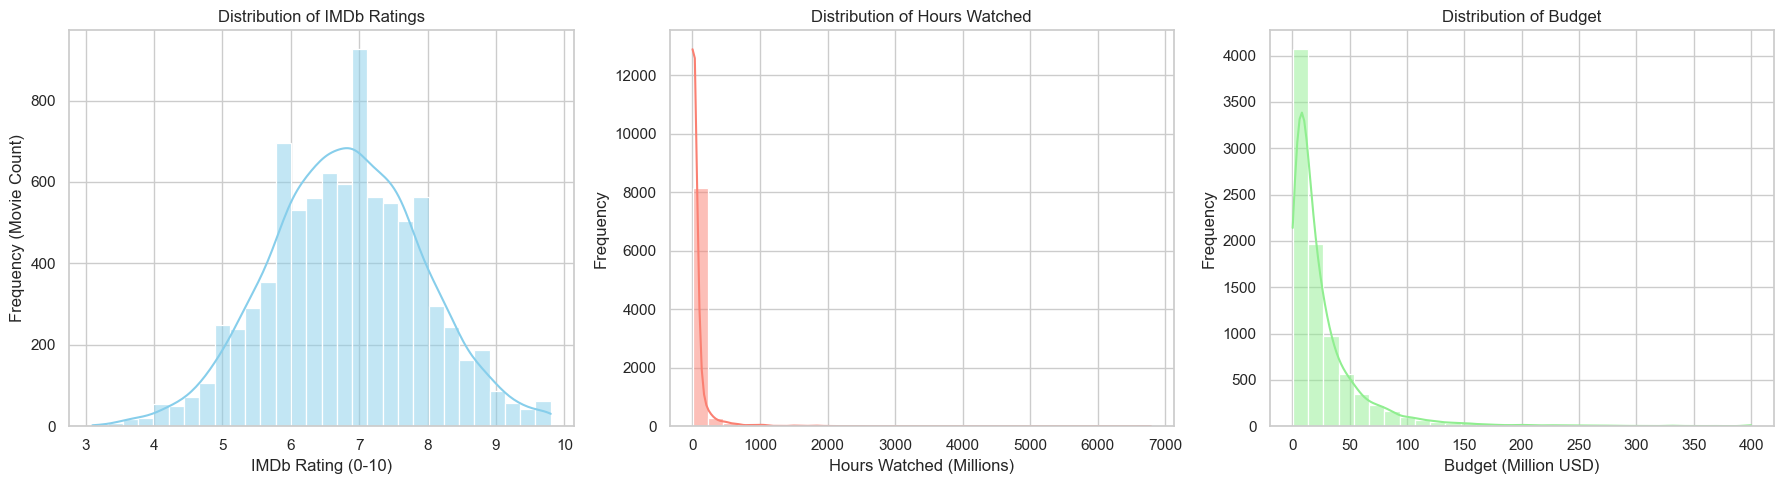

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#IMDb ratings distribution
sns.histplot(df_catalog['imdb_rating'].dropna(), bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of IMDb Ratings')
axes[0].set_xlabel('IMDb Rating (0-10)')
axes[0].set_ylabel('Frequency (Movie Count)')

#Hours Watched distribution
sns.histplot(df_catalog['hours_watched_million'].dropna(), bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Hours Watched')
axes[1].set_xlabel('Hours Watched (Millions)')
axes[1].set_ylabel('Frequency')

#Budget distribution
sns.histplot(df_catalog['budget_million_usd'].dropna(), bins=30, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Budget')
axes[2].set_xlabel('Budget (Million USD)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Insights from the Distribution Histograms

1. **IMDb Ratings Follow a Normal Distribution**
The histogram for IMDb ratings illustrates a classic bell-shaped curve, closely resembling a normal distribution. The central tendency strongly clusters around the 6.5 to 7.0 mark, indicating that the rating system is inherently balanced and robust. This suggests that audiences generally tend to rate most content favorably but moderately, reserving extreme scores for outlier productions. This reliable distribution serves as a solid foundation for evaluating overall content quality without systemic bias

2. **Audience Engagement is Highly Skewed**
Unlike the normal distribution of ratings, the 'hours_watched_million' metric is extremely right skewed. The massive peak near zero indicates that the vast majority of titles generate relatively modest viewership. On the other hand, the long tail extending towards the 7,000 million mark shows that a small group of exceptionally popular hits captures a massive amount of watch time. This suggests that while platforms maintain large catalogs, their actual viewing hours are heavily driven by a select few blockbusters

3. **Feature Film Budget Distribution**
Following our strategic pivot to focus exclusively on movies, the third histogram reveals the true economic landscape of film production. The distribution peaks heavily in the lower to mid budget tiers (under 50 million USD) and exhibits a pronounced right skewed tail extending up to 400 million USD. This clean visualization demonstrates that streaming platforms rely on a high volume of cost-effective standard productions, balanced by a few rare, high risk blockbuster investments

### 2.2 Correlation Analysis

After exploring individual variable distributions, we utilize correlation heatmaps to identify potential linear relationships between our numeric features

Our strategic decision to focus solely on feature films ensures that core variables such as 'budget_million_usd' and 'duration_minutes' are uniformly available across all remaining rows. Consequently, we can execute a comprehensive, global correlation analysis directly on the entire dataset, avoiding the need for separate sub-analyses or manual data filtering

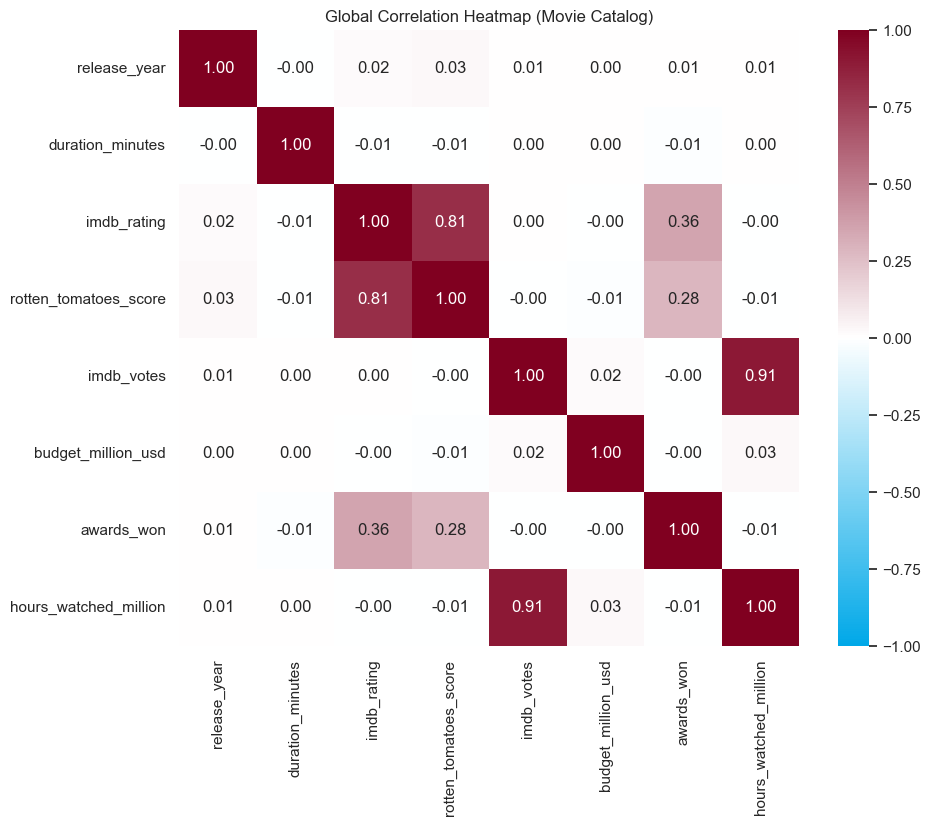

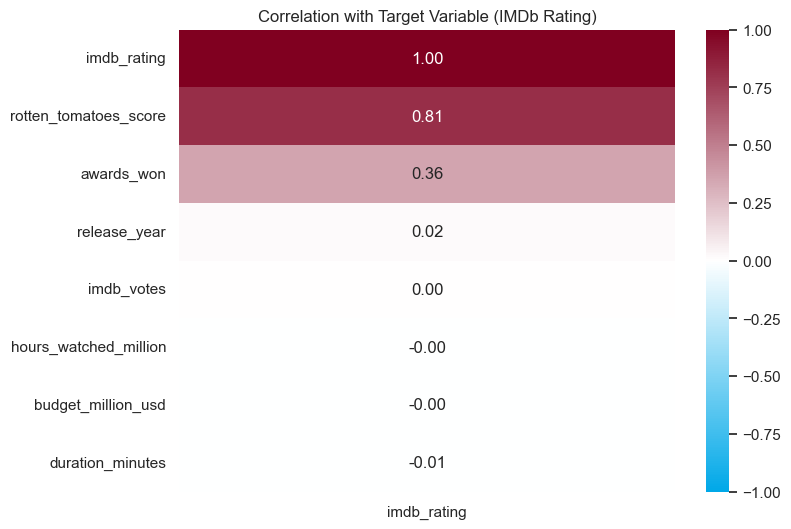


--- Budget & Quality Analysis ---
Correlation between Production Budget and IMDb Rating: -0.004


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

custom_colors = ["#00a8e8", "#ffffff", "#800020"]
my_cmap = LinearSegmentedColormap.from_list("custom_bordeaux_blue", custom_colors)

#select all numeric columns, explicitly excluding the primary key show_id
numeric_cols = df_catalog.select_dtypes(include=['float64', 'int64']).drop(columns=['show_id'], errors='ignore')
corr_matrix = numeric_cols.corr()

#general correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap=my_cmap, fmt=".2f", vmin=-1, vmax=1)
plt.title('Global Correlation Heatmap (Movie Catalog)')
plt.show()

#target variable Heatmap - IMDb rating
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['imdb_rating']].sort_values(by='imdb_rating', ascending=False),  annot=True, cmap=my_cmap, vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation with Target Variable (IMDb Rating)')
plt.show()

#direct inspection of Budget vs. Quality
if 'budget_million_usd' in numeric_cols.columns:
    budget_rating_corr = numeric_cols['budget_million_usd'].corr(numeric_cols['imdb_rating'])
    print("\n--- Budget & Quality Analysis ---")
    print(f'Correlation between Production Budget and IMDb Rating: {budget_rating_corr:.3f}')

### Insights from the Correlation Heatmap

1. **Alignment of Quality Metrics (0.81)**
There is a strong positive correlation (0.81) between 'imdb_rating' and 'rotten_tomatoes_score'. This suggests that critic consensus and audience ratings tend to align, validating both as reliable quality indicators

2. **Audience Engagement Proxy (0.91)**
The high correlation (0.91) between 'imdb_votes' and 'hours_watched_million' demonstrates that titles with higher viewership naturally generate the most engagement. Since 'hours_watched_million' is an internal platform metric, the external voting metric acts as a robust proxy for true audience interest

3. **Budget & Quality: No Linear Relationship**
The global analysis reveals a near zero correlation between 'budget_million_usd' and 'imdb_rating'.
**Business Insight:** This indicates that in our feature film dataset, high budget productions do not automatically guarantee higher ratings or viewership. It challenges the assumption that more expensive equals more successful, suggesting that other qualitative factors (such as genre, cast, or narrative execution) are stronger drivers of a movie's success

4. **Awards as a Secondary Quality Indicator (0.36)**
While most variables show no correlation to the target variable, 'awards_won' presents a weak to moderate positive correlation (0.36) with 'imdb_rating'. This highlights a logical trend: critically acclaimed movies that win awards are generally better received by the broader IMDb audience

### 2.3 Deep Dive - The Relationship Between Budget and Quality

Following the global correlation analysis, which revealed a near zero linear correlation between production budget and IMDb ratings, we must investigate further. Since the correlation coefficient only measures linear relationships, we utilize a scatter plot to determine if there is a hidden non-linear pattern or if the data simply represents unstructured noise

--- Diagnostic Report ---
Total Movies in Dataset: 8704
Budget Stats:
count    8704.000000
mean       27.177746
std        37.416372
min         0.300000
25%         6.700000
50%        15.100000
75%        32.525000
max       400.000000
Name: budget_million_usd, dtype: float64

Real Correlation (Budget vs. Rating): -0.0041


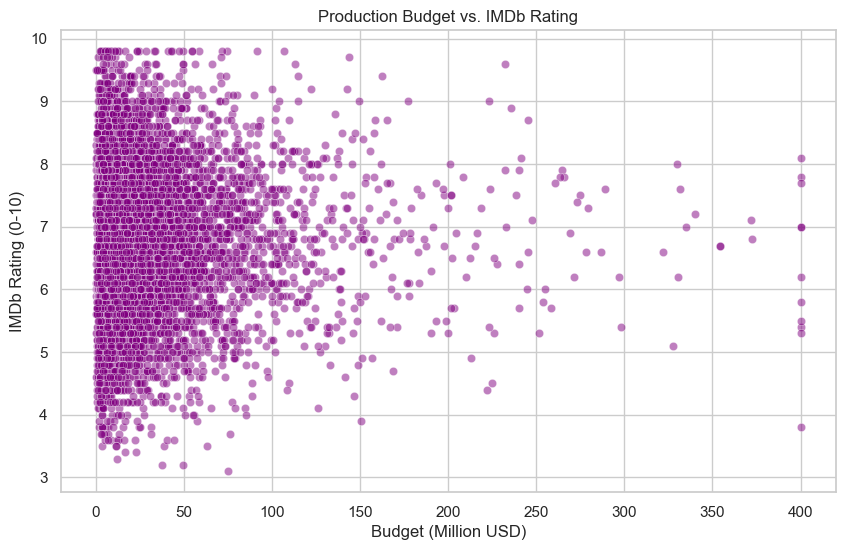

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print('--- Diagnostic Report ---')

#the dataset is already strictly feature films, so we analyze the entire catalog
print(f"Total Movies in Dataset: {len(df_catalog)}")
print(f"Budget Stats:\n{df_catalog['budget_million_usd'].describe()}")

#correlation calculation, to understand the true linear relationship
real_corr = df_catalog['budget_million_usd'].corr(df_catalog['imdb_rating'])
print(f"\nReal Correlation (Budget vs. Rating): {real_corr:.4f}")

#Scatter Plot - visualizing the relationship
#correlation only measures linear trends, if the correlation is near zero, the plot will reveal if there is a nonlinear pattern or pure noise
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_catalog['budget_million_usd'], y=df_catalog['imdb_rating'], alpha=0.5, color='purple')
plt.title('Production Budget vs. IMDb Rating')
plt.xlabel('Budget (Million USD)')
plt.ylabel('IMDb Rating (0-10)')
plt.show()

### Analysis of Production Budget vs. IMDb Rating

#### Statistical Findings:
* **Descriptive Statistics:** The budget distribution shows a mean of approximately 27.18 million USD, with a wide range spanning from 0.3 million to 400 million USD
* **Correlation:** The Pearson correlation coefficient between 'budget_million_usd' and 'imdb_rating' is -0.0041

### Insights from the Budget Analysis

1. **Absence of Linear Correlation (-0.0041)**
The correlation coefficient of -0.0041 indicates virtually no linear relationship between a movie's production budget and its IMDb rating. This suggests that the amount of capital invested does not have a predictive effect on the perceived quality or audience score of the film

2. **Non-Linear Complexity Revealed by Scatter Plot**
Correlation coefficients only measure linear trends. By examining the scatter plot, we observe a dense, dispersed cloud of data points rather than any directional trend line. This visually confirms that the lack of correlation is not a statistical artifact; rather, it reflects a reality where high budget blockbuster productions are just as likely to receive mediocre ratings as low budget indie films

3. **Strategic Business Takeaway**
The data challenges the traditional industry assumption that more expensive equals more successful. Audience satisfaction appears to be driven by factors entirely decoupled from financial investment, such as script quality, genre appeal, or narrative execution. For a streaming platform's content strategy, this implies that acquiring or producing ultra expensive blockbusters is a high risk gamble that does not inherently guarantee higher user satisfaction compared to cost-effective productions

### 2.4 Time-Series Momentum: Autocorrelation Analysis

After analyzing the correlations between different variables, we now apply an Autocorrelation test to investigate the momentum of the film industry over time:

1. **Volume Momentum (Movie Releases):** Does a year with a massive volume of movie releases predict an equally high volume the following year? This indicates whether the industry is experiencing sustained production growth
2. **Financial Momentum (Average Budget):** Are average production budgets escalating consistently year over year? By dynamically calculating the yearly average directly from our cleaned feature film catalog, we can identify whether the industry experiences sustained periods of budget inflation or contraction

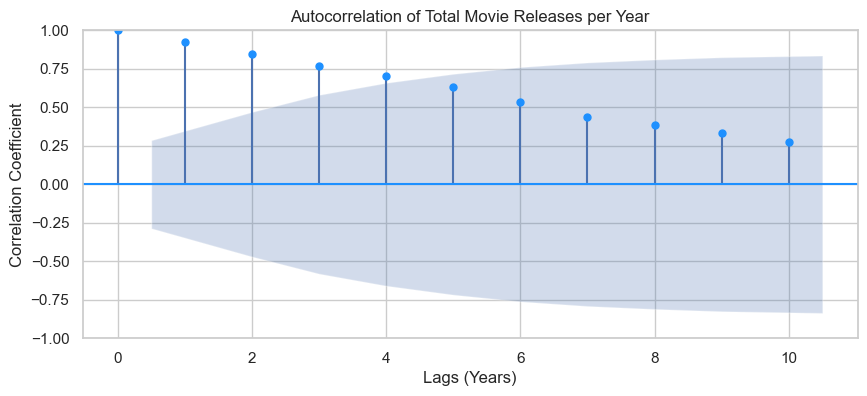

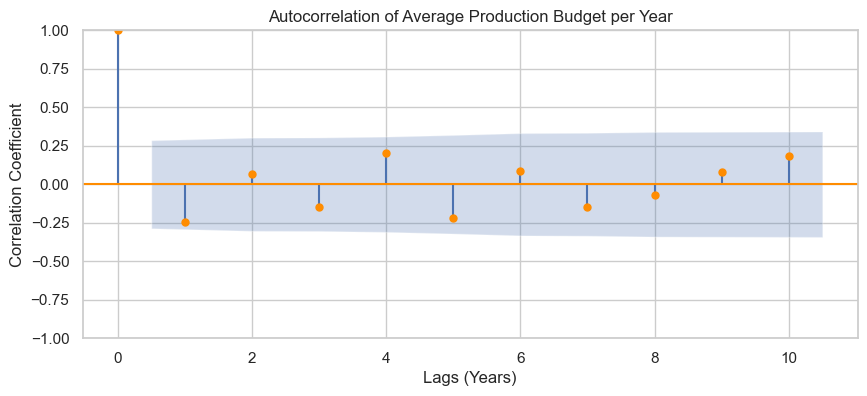

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

#Autocorrelation for total movies released, dynamically calculate the yearly volume from our cleaned, only movies from catalog
yearly_movie_volume = df_catalog.groupby('release_year').size()

plt.figure(figsize=(10, 4))
plot_acf(yearly_movie_volume.dropna(), lags=10, ax=plt.gca(), color='dodgerblue')
plt.title('Autocorrelation of Total Movie Releases per Year')
plt.xlabel('Lags (Years)')
plt.ylabel('Correlation Coefficient')
plt.show()

#Autocorrelation for average movie budget, dynamically calculate the yearly average budget from our cleaned catalog
yearly_budget = df_catalog.groupby('release_year')['budget_million_usd'].mean()

plt.figure(figsize=(10, 4))
plot_acf(yearly_budget.dropna(), lags=10, ax=plt.gca(), color='darkorange')
plt.title('Autocorrelation of Average Production Budget per Year')
plt.xlabel('Lags (Years)')
plt.ylabel('Correlation Coefficient')
plt.show()

### Autocorrelation Analysis

To evaluate industry trends, we applied an Autocorrelation test. This measures the memory of our data, specifically how strongly a value in one year correlates with the values of previous years

1. **Volume Momentum: Sustained Industry Growth**
The plot for 'Total Movie Releases per Year' shows a strong, slowly decaying positive correlation across the first 5 to 6 lags. This confirms high momentum: a high volume release year predicts continued high output in the near term. This suggests that platforms operate on multi year content roadmaps, driving sustained industry expansion rather than random year to year fluctuations

2. **Financial Momentum: Adaptive Budgeting**
In contrast, the plot for 'Average Production Budget per Year' shows that almost all lags fall within the confidence interval (the shaded blue area), with points fluctuating closely around the zero line. This indicates no long term statistical memory. Unlike content volume, budget allocation does not follow a fixed historical path

3. **Strategic Business Takeaway**
The industry demonstrates a clear divergence in strategy:
* **Content Scaling:** Platforms employ a momentum based growth strategy for volume, where past output influences near term production goals to build a larger library
* **Financial Agility:** Platforms maintain strict financial flexibility. The lack of autocorrelation in budgets confirms that annual investment is not anchored to historical averages. Instead, budgets are reactive adjusted dynamically based on the specific requirements of the content slate and current market opportunities each year

### 2.5 Frequencies and Proportions - Pie & Bar Charts

To understand the composition of our movie catalog, we utilize both pie and bar charts to visualize content frequencies and market concentration. 

Instead of a basic content-type split (as our dataset is now exclusively feature films), the pie chart illustrates the market concentration of the top 5 largest genres against the rest of the catalog. Alongside it, a detailed bar chart breaks down the absolute frequencies of the top 10 leading genres, providing a clear view of platform acquisition strategies

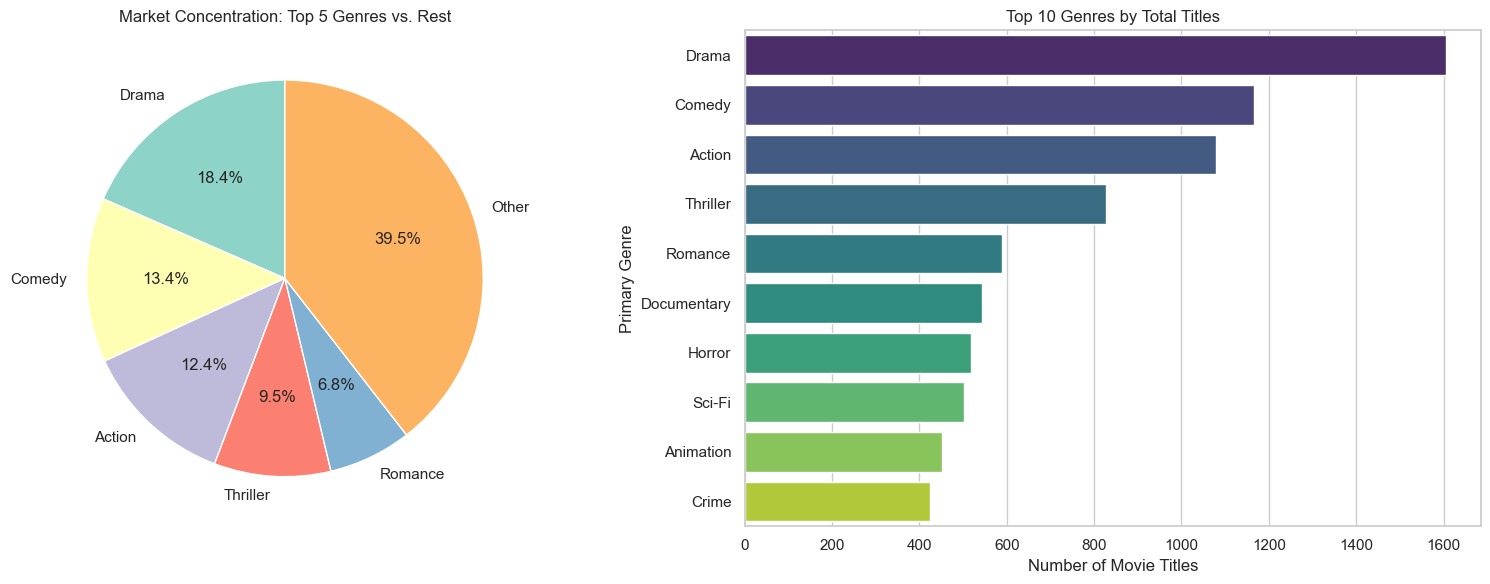

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Pie Chart - market concentration (Top 5 Genres vs. Other)
genre_counts = df_catalog['primary_genre'].value_counts()
top_5_genres = genre_counts.head(5)
other_genres_count = genre_counts.iloc[5:].sum()

#combine for the pie chart
pie_data = top_5_genres.copy()
pie_data['Other'] = other_genres_count

axes[0].pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette("Set3"))
axes[0].set_title('Market Concentration: Top 5 Genres vs. Rest')

#Bar Chart - top 10 genres by frequency
top_10_genres = genre_counts.head(10)
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, ax=axes[1], palette='viridis', hue=top_10_genres.index, legend=False)
axes[1].set_title('Top 10 Genres by Total Titles')
axes[1].set_xlabel('Number of Movie Titles')
axes[1].set_ylabel('Primary Genre')

plt.tight_layout()
plt.show()

### Insights from Frequencies and Proportions

1. **High Market Concentration in Top Genres**
The pie chart reveals a significant concentration within the film market: the top 5 genres alone (Drama, Comedy, Action, Thriller, Romance) account for over 60% of the entire catalog. The remaining 40% is fragmented across all other genres combined. This indicates that platform acquisition and production strategies are heavily weighted towards a few universally appealing core genres, rather than spreading investments evenly across niche categories

2. **The "Safe Bet" Dominance**
The bar chart clearly shows that Drama (18.4%) and Comedy (13.4%) massively dominate the catalog, followed by Action. While a preliminary business recommendation might be to advise streaming companies to focus strictly on these top genres, we must remain critical of this distribution. Further investigation is needed to determine whether drama and comedy dominate because they are genuinely the most demanded and profitable by audiences, or simply because they are the "safe bets" - often being the most cost-effective and straightforward genres to produce en masse

### 2.6 Outliers and Variance - Quality Metrics Comparison

We utilize box plots to examine the variance and identify potential outliers across our primary quality metrics: 'imdb_rating' and 'rotten_tomatoes_score'. Although our correlation heatmap established a quite high linear relationship (0.81) between them, we wanted to visually inspect their distributions side by side. To achieve a true comparison, we normalized the Rotten Tomatoes scores (originally 0-100) down to a 0-10 scale

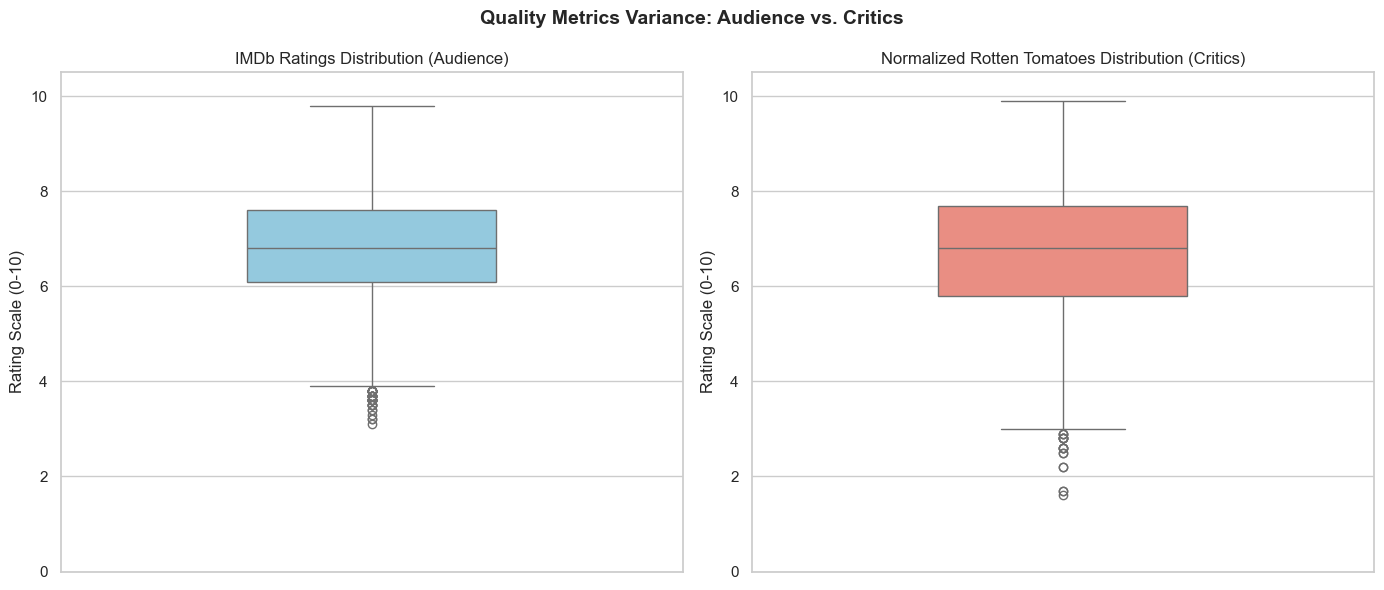

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

#normalizing Rotten Tomatoes from 0-100 to a 0-10 scale for direct comparison
df_catalog['rt_normalized'] = df_catalog['rotten_tomatoes_score'] / 10
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#BoxPlot for IMDb ratings
sns.boxplot(y='imdb_rating', data=df_catalog, color='skyblue', ax=axes[0], width=0.4)
axes[0].set_title('IMDb Ratings Distribution (Audience)')
axes[0].set_ylabel('Rating Scale (0-10)')
axes[0].set_ylim(0, 10.5) # Setting fixed limits for perfect visual comparison

#BoxPlot for normalized rotten tomatoes
sns.boxplot(y='rt_normalized', data=df_catalog, color='salmon', ax=axes[1], width=0.4)
axes[1].set_title('Normalized Rotten Tomatoes Distribution (Critics)')
axes[1].set_ylabel('Rating Scale (0-10)')
axes[1].set_ylim(0, 10.5)

plt.suptitle('Quality Metrics Variance: Audience vs. Critics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#drop the temporary normalized column so it doesn't clutter the dataset
df_catalog = df_catalog.drop(columns=['rt_normalized'])

### Insights from the Normalized Box Plots

1. **Highly Consistent Core Distributions** The core statistical metrics (the median, as well as the 25th and 75th percentiles) are remarkably similar between the IMDb and Rotten Tomatoes. When placed on the exact same scale, their central tendencies align almost perfectly around the 6.5-7 mark, demonstrating that critics and general audiences generally agree on the baseline quality of most films

2. **Presence of Negative Outliers** Both rating systems exhibit a significant number of negative outliers (stretching downwards below the bottom whisker). These represent titles that were heavily criticized and scored exceptionally low

3. **Business Decision - Prioritizing IMDb** We previously identified a strong positive correlation (0.81) between 'imdb_rating' and 'rotten_tomatoes_score', which suggests that both metrics largely capture the exact same quality signal. Furthermore, our box plot analysis visually confirms this redundancy, while also revealing that 'imdb_rating' has a tighter interquartile range and fewer extreme negative outliers (stopping around 3.0, unlike RT which drops below 2.0). Given this redundancy and the superior statistical stability of IMDb, we will retain 'imdb_rating' as our single primary quality metric and drop 'rotten_tomatoes_score' to reduce multicollinearity and streamline our feature set

### 2.7 Aggregations and Pivot Tables

To extract comprehensive business insights, we execute a two-tiered aggregation analysis. First, we generate a global summary to compare overall platform performance in terms of average quality ('imdb_rating') and total engagement ('hours_watched_million'). Second, we construct a multidimensional pivot table that cross-references these platforms with the top 5 dominant genres, revealing which provider leads in specific market segments

In [20]:
import pandas as pd

print("--- Global Platform Performance Summary ---")
#overall summary per platform- global view
platform_summary = df_catalog.groupby('platform').agg(average_imdb_rating=('imdb_rating', 'mean'), total_hours_watched_million=('hours_watched_million', 'sum')).round(2)

display(platform_summary)


print(" \n --- Deep Dive Pivot Table - Platform vs. Top 5 Genres ---")
#top 5 genres for the cross reference
top_5_genres = df_catalog['primary_genre'].value_counts().head(5).index
df_top_genres = df_catalog[df_catalog['primary_genre'].isin(top_5_genres)]

#multi-dimensional PivotTable
pivot_summary = pd.pivot_table(
    df_top_genres, 
    values=['imdb_rating', 'hours_watched_million'], 
    index='platform', 
    columns='primary_genre', 
    aggfunc={'imdb_rating': 'mean', 'hours_watched_million': 'sum'}
).round(2)

display(pivot_summary)

--- Global Platform Performance Summary ---


,average_imdb_rating,total_hours_watched_million
platform,,
Amazon Prime Video,6.78,158217.0
Apple TV+,7.13,19940.0
Crunchyroll,6.75,5798.0
Disney+,6.79,81756.0
HBO Max,7.02,49817.0
Hulu,6.79,65578.0
JioCinema,6.76,12633.0
Netflix,6.75,200404.0
Paramount+,6.85,30998.0


 
 --- Deep Dive Pivot Table - Platform vs. Top 5 Genres ---


hours_watched_million                                      \
primary_genre                     Action   Comedy    Drama  Romance Thriller   
platform                                                                       
Amazon Prime Video               12960.0  26888.0  37519.0   5971.0  14963.0   
Apple TV+                         2005.0   2529.0   2031.0   1304.0   1578.0   
Crunchyroll                       2048.0    573.0   1546.0     79.0     97.0   
Disney+                          12494.0  12096.0  13747.0   7421.0   4986.0   
HBO Max                           9342.0   3359.0   9158.0   2606.0   5464.0   
Hulu                              6372.0   5878.0  10590.0   9150.0   9654.0   
JioCinema                         2619.0    429.0   4719.0    826.0    715.0   
Netflix                          21537.0  26836.0  23726.0  14360.0  13374.0   
Paramount+                        2502.0   1568.0   4722.0   3121.0   5260.0   
Peacock                           2068.0   3168.0   2532.0   2151.0   1967.0   

                   imdb_rating                                
primary_genre           Action Comedy Drama Romance Thriller  
platform                                                      
Amazon Prime Video        6.65   6.82  6.80    6.86     6.86  
Apple TV+                 7.12   7.09  7.14    6.61     7.15  
Crunchyroll               6.67   6.43  6.85    6.86     6.96  
Disney+                   6.63   7.01  6.82    6.72     6.72  
HBO Max                   6.98   7.05  7.13    6.98     7.01  
Hulu                      6.84   6.72  6.67    6.65     6.77  
JioCinema                 6.93   6.98  6.73    6.83     6.40  
Netflix                   6.83   6.75  6.74    6.78     6.76  
Paramount+                6.75   7.09  6.95    6.92     6.52  
Peacock                   6.69   6.74  6.80    6.70     6.57

### Insights from the Platform & Genre Pivot Tables

1. **The Quality vs. Volume Strategy Divide**
The global summary reveals two distinctly different business models in the streaming market. Netflix and Amazon Prime Video operate as Mass Market Giants, capturing massive audience engagement (both exceeding 150,000 million hours watched) while maintaining industry average ratings (~6.75). Conversely, Apple TV+ (7.13) and HBO Max (7.02) operate as "Premium Boutiques", prioritizing highly rated, critically acclaimed content over sheer viewership volume

2. **Cross-Platform Baseline Stability**
Despite these differing strategies, average IMDb ratings across the industry remain remarkably stable, hovering tightly within the 6.68 to 7.13 range. This indicates a highly competitive baseline for audience satisfaction - no single platform has a monopoly on "good" content, and users generally experience a consistent baseline of quality regardless of their subscription

3. **Genre-Specific Market Capture**
The deep dive pivot table highlights a gap between quality and engagement within the top 5 genres. For example, while Apple TV+ and HBO Max consistently deliver the highest rated Drama and Action titles (scoring ~7.00 to 7.14), Netflix and Amazon completely dominate the actual watch time in these exact same categories. This suggests that platform ubiquity, algorithmic recommendations, and accessibility often trump slight increases in pure cinematic quality when it comes to generating viewer engagement

### 2.8 Final Feature Selection & Refinement

Based on our EDA, we finalize our dataset features before moving to the final export phase. Since structural missing values (>40%) and TV Show records were already handled during the initial ETL pipeline, our final refinement focuses strictly on removing redundant metrics across all tables to prevent multicollinearity:

1. **Redundancy Removal (Quality):** We drop 'rotten_tomatoes_score'. As established visually and statistically, 'imdb_rating' provides a more stable quality metric with fewer outliers and shares a high correlation (0.81) with Rotten Tomatoes, making the latter redundant. 
2. **Aggregated Metric Consistency:** We drop the 'avg_rt' (Average Rotten Tomatoes) column from all summary tables. Because summary tables contain very few rows, mathematical correlation tests are statistically invalid. However, relying on our raw data findings, which proved Rotten Tomatoes to be a redundant metric compared to IMDb, we consistently eliminate it globally
3. **Redundancy Removal (Engagement):** We drop 'imdb_votes'. Our analysis showed a remarkably strong correlation (0.91) between votes and 'hours_watched_million'. Since watch hours represent a more accurate, internal platform metric for actual viewer engagement, the external voting metric is no longer needed
4. **Preservation of Segmented Features:** The 'budget_million_usd' column remains explicitly protected as a key quantitative variable for movie specific financial analysis, maintaining our structural logic

In [21]:
#drop redundant metrics from the main catalog
columns_to_drop = ['rotten_tomatoes_score', 'imdb_votes']
df_catalog = df_catalog.drop(columns=columns_to_drop, errors='ignore')

#drop the aggregated avg_rt from ALL summary tables dynamically
for dataset_name, df_current in datasets.items():
    #find any column that represents average or total votes, plus the average RT
    cols_to_drop_summary = [col for col in df_current.columns if col in ['avg_rt', 'avg_votes', 'total_votes']]
    if cols_to_drop_summary:
        datasets[dataset_name] = df_current.drop(columns=cols_to_drop_summary)

#synchronize the updated main catalog back into datasets dictionary
datasets['Streaming Catalog'] = df_catalog

#comprehensive quality check- print final dimensions for ALL tables
print("---- FINAL DATASET DIMENSIONS REPORT (POST-EDA) ----")
for dataset_name, df_current in datasets.items():
    print(f"{dataset_name:<25} | Rows: {df_current.shape[0]:<6} | Columns: {df_current.shape[1]}")

---- FINAL DATASET DIMENSIONS REPORT (POST-EDA) ----
Streaming Catalog         | Rows: 8704   | Columns: 15
Platform Summary          | Rows: 10     | Columns: 7
Genre Summary             | Rows: 21     | Columns: 6
Country Summary           | Rows: 24     | Columns: 5
Yearly Release Trends     | Rows: 47     | Columns: 5


### 2.9 Feature Provenance & Export Preparation

As we conclude the Exploratory Data Analysis (EDA) phase and transition into Machine Learning and Tableau dashboarding, we must structure our datasets for complex multitable joins

**Overlapping Column Names:** In the upcoming Machine Learning pipeline, we will merge our datasets using our primary key ('show_id'). A common issue during this step is that different tables might contain columns with the exact same name. If we merge them as is, pandas will automatically attach default suffixes to these columns. This leads to messy, uninterpretable feature names that can easily complicate both the predictive modeling process and the BI. Beyond preventing technical issues, adding these explicit prefixes allows us to instantly identify the original source table of any recurring metric at a glance

**The Dynamic Renaming Solution:** To prevent this ambiguity, we implement a dynamic scanning script. This algorithm systematically scans all datasets, counts the frequency of every column name, and identifies features that overlap across multiple tables. It then automatically prepends a dataset specific prefix to these overlapping columns, for an exmplae turning 'budget' into 'catalog_budget' 

Crucially, the script explicitly protects our primary key ('show_id') from being renamed, ensuring our tables can still connect seamlessly. Finally, we overwrite our existing '_CLEAN.csv' files to keep our database snapshot synchronized and fully prepared for the ML phase

In [22]:
from collections import Counter
import pandas as pd

#gather all column names from all datasets to identify overlaps
all_columns = []
for df in datasets.values():
    all_columns.extend(df.columns.tolist())

#count frequencies and identify overlapping columns (appear > 1)
column_counts = Counter(all_columns)
overlapping_columns = {col for col, count in column_counts.items() if count > 1}

#explicitly protect the primary key from being renamed
primary_key = 'show_id'
if primary_key in overlapping_columns:
    overlapping_columns.remove(primary_key)

print(f"Detected overlapping columns to rename: {overlapping_columns} \n")

#loop through all datasets and rename ONLY the overlapping columns
for dataset_name, df_current in datasets.items():
    #create a clean prefix from the dataset name
    prefix = dataset_name.lower().replace(' ', '_') + '_'
    
    rename_dict = {}
    for col in df_current.columns:
        if col in overlapping_columns:
            rename_dict[col] = f"{prefix}{col}"
    
    #apply renaming if overlaps exist in this specific dataset
    if rename_dict:
        datasets[dataset_name] = df_current.rename(columns=rename_dict)
        print(f"Renamed in '{dataset_name}': {rename_dict}")
        display(datasets[dataset_name].head(2))

#export and overwrite existing clean datasets
print("\n--- UPDATING EXISTING CLEAN DATASETS ---")
for dataset_name, df_current in datasets.items():
    file_name = dataset_name.lower().replace(' ', '_')
    clean_path = f'data/{file_name}_CLEAN.csv'
    
    #export and overwrite the existing CSV
    df_current.to_csv(clean_path, index=False)
    print(f"Updated and saved: {clean_path} (Rows: {df_current.shape[0]}, Columns: {df_current.shape[1]})")

Detected overlapping columns to rename: {'avg_imdb', 'avg_budget', 'platform', 'country', 'movies', 'release_year', 'top_genre', 'total_awards', 'total_titles', 'primary_genre', 'total_hours_watched_million'} 

Renamed in 'Streaming Catalog': {'platform': 'streaming_catalog_platform', 'primary_genre': 'streaming_catalog_primary_genre', 'country': 'streaming_catalog_country', 'release_year': 'streaming_catalog_release_year'}


,show_id,title,streaming_catalog_platform,streaming_catalog_primary_genre,genres,streaming_catalog_country,language,streaming_catalog_release_year,rating,duration_minutes,imdb_rating,budget_million_usd,production_company,awards_won,hours_watched_million
0,1,When the Stars Fall,Netflix,Drama,"Drama, War, Mystery",Germany,German,2007,R,102.0,6.3,15.7,Marvel Studios,0,7.0
1,2,A Silent Echo,Amazon Prime Video,Thriller,"Thriller, Adventure",France,French,1996,R,105.0,7.5,184.9,Illumination,0,4.0


Renamed in 'Platform Summary': {'platform': 'platform_summary_platform', 'total_titles': 'platform_summary_total_titles', 'movies': 'platform_summary_movies', 'avg_imdb': 'platform_summary_avg_imdb', 'total_hours_watched_million': 'platform_summary_total_hours_watched_million', 'total_awards': 'platform_summary_total_awards', 'top_genre': 'platform_summary_top_genre'}


,platform_summary_platform,platform_summary_total_titles,platform_summary_movies,platform_summary_avg_imdb,platform_summary_total_hours_watched_million,platform_summary_total_awards,platform_summary_top_genre
0,Amazon Prime Video,3341,1921,6.78,259376,1003,Drama
1,Apple TV+,734,428,7.12,36664,270,Drama


Renamed in 'Genre Summary': {'primary_genre': 'genre_summary_primary_genre', 'total_titles': 'genre_summary_total_titles', 'avg_imdb': 'genre_summary_avg_imdb', 'total_hours_watched_million': 'genre_summary_total_hours_watched_million', 'avg_budget': 'genre_summary_avg_budget', 'total_awards': 'genre_summary_total_awards'}


...

Renamed in 'Country Summary': {'country': 'country_summary_country', 'total_titles': 'country_summary_total_titles', 'avg_imdb': 'country_summary_avg_imdb', 'top_genre': 'country_summary_top_genre'}


,country_summary_country,country_summary_total_titles,country_summary_avg_imdb,top_platform,country_summary_top_genre
0,Argentina,149,6.70,Netflix,Drama
1,Australia,294,6.74,Netflix,Drama


Renamed in 'Yearly Release Trends': {'release_year': 'yearly_release_trends_release_year', 'total_titles': 'yearly_release_trends_total_titles', 'movies': 'yearly_release_trends_movies', 'avg_imdb': 'yearly_release_trends_avg_imdb', 'avg_budget': 'yearly_release_trends_avg_budget'}


,yearly_release_trends_release_year,yearly_release_trends_total_titles,yearly_release_trends_movies,yearly_release_trends_avg_imdb,yearly_release_trends_avg_budget
0,1980,87,52,6.56,29.06
1,1981,81,40,6.59,21.25



--- UPDATING EXISTING CLEAN DATASETS ---
Updated and saved: data/streaming_catalog_CLEAN.csv (Rows: 8704, Columns: 15)
Updated and saved: data/platform_summary_CLEAN.csv (Rows: 10, Columns: 7)
Updated and saved: data/genre_summary_CLEAN.csv (Rows: 21, Columns: 6)
Updated and saved: data/country_summary_CLEAN.csv (Rows: 24, Columns: 5)
Updated and saved: data/yearly_release_trends_CLEAN.csv (Rows: 47, Columns: 5)
